ANALISI PRELIMINARE DEI DATI
Dimensioni del dataset (Righe, Colonne): (569, 30)
Distribuzione delle classi:
target
1    357
0    212
Name: count, dtype: int64
Percentuale Classi:
target
1    62.741652
0    37.258348
Name: proportion, dtype: float64

VERIFICA DELLE DIVISIONI
Campioni nel Training set:   397 (69.8%)
Campioni nel Validation set: 86 (15.1%)
Campioni nel Test set:       86 (15.1%)

RISULTATI PCA
Varianza spiegata dalla PC1: 44.49%
Varianza spiegata dalla PC2: 18.79%
Varianza totale spiegata dalle 2 componenti: 63.28%


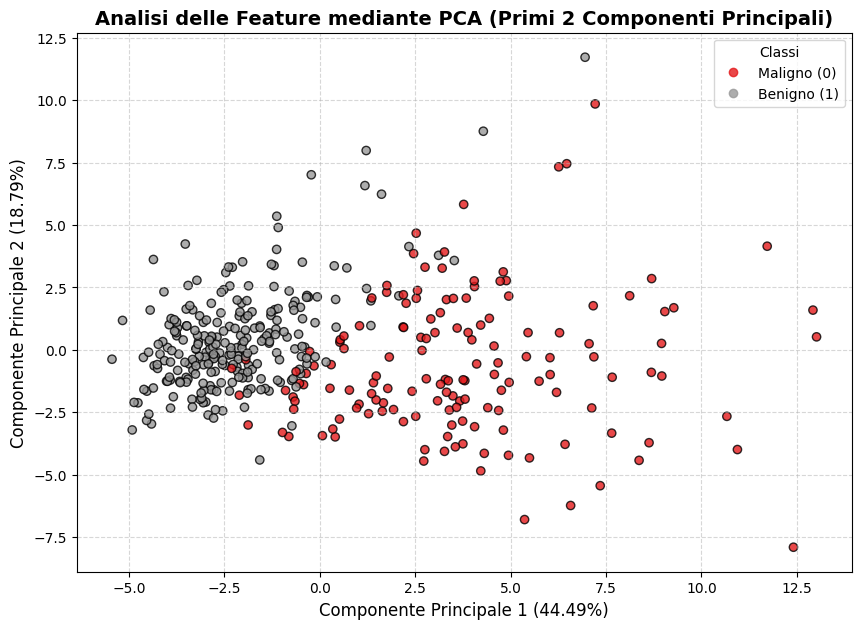

In [ ]:
# PARTE 1 - PROGETTO APPRENDIMENTO AUTOMATICO E APPRENDIMENTO PROFONDO

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Caricamento del Dataset
cancer_data = load_breast_cancer()
X = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)
y = pd.Series(cancer_data.target, name='target') # 0 = Maligno, 1 = Benigno

print("ANALISI PRELIMINARE DEI DATI")
print(f"Dimensioni del dataset (Righe, Colonne): {X.shape}")
print(f"Distribuzione delle classi:\n{y.value_counts()}")
print(f"Percentuale Classi:\n{y.value_counts(normalize=True) * 100}\n")

# Suddivisione in Train, Validation e Test (70% / 15% / 15%)
# Primo split: separiamo il Test Set (15% del totale)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

# Secondo split: dividiamo il restante 85% in Train (70% totale) e Validation (15% totale)
# 0.1765 è la proporzione corretta per ottenere esattamente il 15% sul totale iniziale (0.15 / 0.85 ≈ 0.1765)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.1765, random_state=42, stratify=y_train_val
)

print("VERIFICA DELLE DIVISIONI")
print(f"Campioni nel Training set:   {X_train.shape[0]} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Campioni nel Validation set: {X_val.shape[0]} ({len(X_val)/len(X)*100:.1f}%)")
print(f"Campioni nel Test set:       {X_test.shape[0]} ({len(X_test)/len(X)*100:.1f}%)")

# Preprocessing (standardizzazione)
scaler = StandardScaler()
# Calcoliamo i parametri solo sul train e trasformiamo
X_train_scaled = scaler.fit_transform(X_train)
# Trasformiamo validation e test usando i parametri del train
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Implementazione PCA
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)

# Calcolo della varianza spiegata
var_spiegata_1 = pca.explained_variance_ratio_[0] * 100
var_spiegata_2 = pca.explained_variance_ratio_[1] * 100
var_totale = pca.explained_variance_ratio_.sum() * 100

print("\nRISULTATI PCA")
print(f"Varianza spiegata dalla PC1: {var_spiegata_1:.2f}%")
print(f"Varianza spiegata dalla PC2: {var_spiegata_2:.2f}%")
print(f"Varianza totale spiegata dalle 2 componenti: {var_totale:.2f}%")

# Visualizzazione Grafica della PCA
plt.figure(figsize=(10, 7))
# Creiamo un grafico a dispersione distinguendo le classi con i colori
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='Set1', alpha=0.8, edgecolors='k')

# Configurazione grafica ed etichette
plt.title('Analisi delle Feature mediante PCA (Primi 2 Componenti Principali)', fontsize=14, fontweight='bold')
plt.xlabel(f'Componente Principale 1 ({var_spiegata_1:.2f}%)', fontsize=12)
plt.ylabel(f'Componente Principale 2 ({var_spiegata_2:.2f}%)', fontsize=12)

# Aggiungiamo la legenda
classes = ['Maligno (0)', 'Benigno (1)']
plt.legend(handles=scatter.legend_elements()[0], labels=classes, title="Classi")
plt.grid(True, linestyle='--', alpha=0.5)

# Mostriamo il grafico
plt.show()

In [ ]:
# PARTE 2 - PROGETTO APPRENDIMENTO AUTOMATICO E APPRENDIMENTO PROFONDO
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# SPERIMENTAZIONE E TUNING SUL VALIDATION SET
print("FASE DI TUNING SUL VALIDATION SET")

# 1 Tuning Regressione Logistica (Iperparametro C)
best_lr_acc = 0
best_c_lr = 1.0
for c in [0.01, 0.1, 1.0, 10.0]:
    clf = LogisticRegression(C=c, random_state=42, max_iter=10000)
    clf.fit(X_train_scaled, y_train)
    val_acc = accuracy_score(y_val, clf.predict(X_val_scaled))
    if val_acc > best_lr_acc:
        best_lr_acc = val_acc
        best_c_lr = c
print(f"Miglior C per Regr. Logistica: {best_c_lr} (Validation Accuracy: {best_lr_acc:.4f})")

# 2 Tuning SVM (Iperparametro C)
best_svm_acc = 0
best_c_svm = 1.0
for c in [0.01, 0.1, 1.0, 10.0]:
    clf = SVC(C=c, kernel='linear', probability=True, random_state=42)
    clf.fit(X_train_scaled, y_train)
    val_acc = accuracy_score(y_val, clf.predict(X_val_scaled))
    if val_acc > best_svm_acc:
        best_svm_acc = val_acc
        best_c_svm = c
print(f"Miglior C per SVM Linear: {best_c_svm} (Validation Accuracy: {best_svm_acc:.4f})")

# 3 Tuning Random Forest (Iperparametro n_estimators)
best_rf_acc = 0
best_est_rf = 100
for n_est in [10, 50, 100, 200]:
    clf = RandomForestClassifier(n_estimators=n_est, random_state=42)
    clf.fit(X_train_scaled, y_train)
    val_acc = accuracy_score(y_val, clf.predict(X_val_scaled))
    if val_acc > best_rf_acc:
        best_rf_acc = val_acc
        best_est_rf = n_est
print(f"Miglior n_estimators per Random Forest: {best_est_rf} (Validation Accuracy: {best_rf_acc:.4f})\n")


# ADDESTRAMENTO FINALE E VALUTAZIONE SUL TEST SET
# Definiamo i modelli finali con i migliori iperparametri trovati
models = {
    "Regressione Logistica": LogisticRegression(C=best_c_lr, random_state=42, max_iter=10000),
    "SVM": SVC(C=best_c_svm, kernel='linear', probability=True, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=best_est_rf, random_state=42)
}

# Dizionario per salvare le metriche e le probabilità (utili dopo per la curva ROC)
test_results = {}
predictions_prob = {}
predictions_label = {}

print("VALUTAZIONE FINALE SUL TEST SET")
for name, model in models.items():
    # Uniamo Train e Validation per il refit finale per sfruttare più dati
    X_train_final_scaled = np.vstack((X_train_scaled, X_val_scaled))
    y_train_final = np.concatenate((y_train, y_val))

    # Addestramento finale
    model.fit(X_train_final_scaled, y_train_final)

    # Predizioni sul Test Set
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1] # Probabilità per la classe 1 (Benigno)

    # Salviamo le predizioni per i grafici successivi
    predictions_label[name] = y_pred
    predictions_prob[name] = y_prob

    # Calcolo di tutte le metriche
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    test_results[name] = [acc, prec, rec, f1, roc_auc]

    print(f"\n{name}")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"ROC AUC:   {roc_auc:.4f}")

FASE DI TUNING SUL VALIDATION SET
Miglior C per Regr. Logistica: 0.1 (Validation Accuracy: 1.0000)
Miglior C per SVM Linear: 0.1 (Validation Accuracy: 1.0000)
Miglior n_estimators per Random Forest: 10 (Validation Accuracy: 0.9651)

VALUTAZIONE FINALE SUL TEST SET

Regressione Logistica
Accuracy:  0.9767
Precision: 0.9815
Recall:    0.9815
F1-Score:  0.9815
ROC AUC:   0.9942

SVM
Accuracy:  0.9767
Precision: 0.9815
Recall:    0.9815
F1-Score:  0.9815
ROC AUC:   0.9919

Random Forest
Accuracy:  0.9070
Precision: 0.9600
Recall:    0.8889
F1-Score:  0.9231
ROC AUC:   0.9884


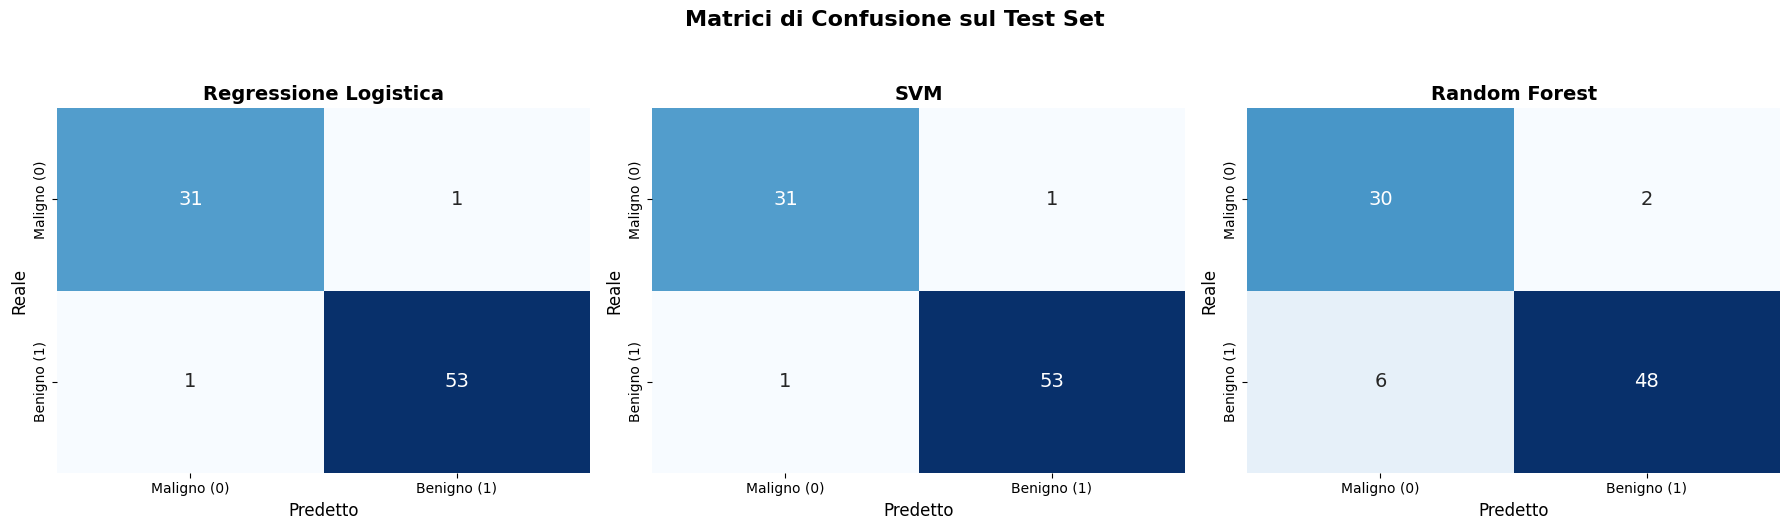

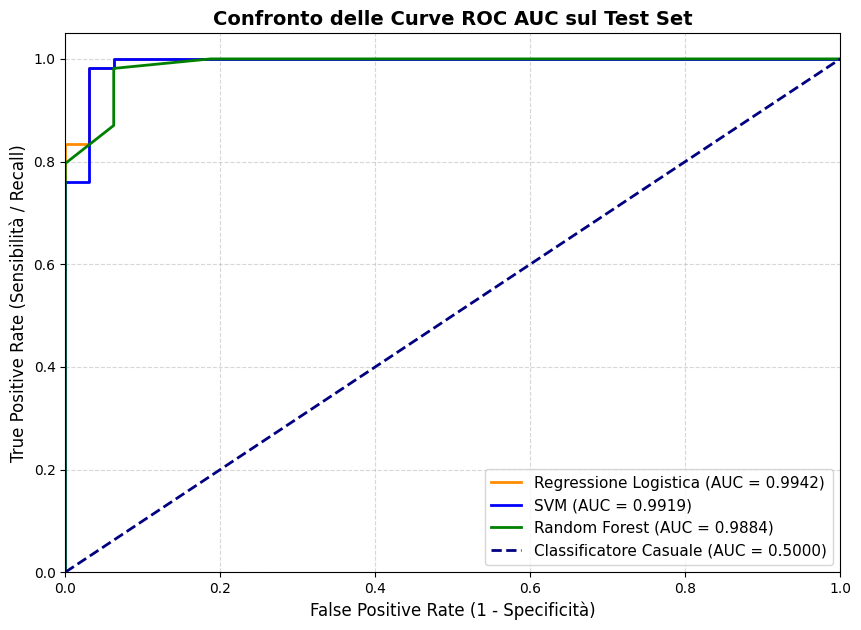

In [ ]:
# PARTE 3 - PROGETTO APPRENDIMENTO AUTOMATICO E APPRENDIMENTO PROFONDO
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, confusion_matrix, roc_curve, auc

# GRAFICO 1: LE MATRICI DI CONFUSIONE
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Matrici di Confusione sul Test Set', fontsize=16, fontweight='bold', y=1.05)

# Iteriamo sui modelli per creare i subplots
for i, (name, y_pred) in enumerate(predictions_label.items()):
    cm = confusion_matrix(y_test, y_pred)

    # Usiamo seaborn per rendere la matrice più accattivante
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False,
                xticklabels=['Maligno (0)', 'Benigno (1)'],
                yticklabels=['Maligno (0)', 'Benigno (1)'], annot_kws={"size": 14})

    axes[i].set_title(name, fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Predetto', fontsize=12)
    axes[i].set_ylabel('Reale', fontsize=12)

plt.tight_layout()
plt.show()

print("\n")

# GRAFICO 2: LE CURVE ROC AUC SOVRAPPOSTE
plt.figure(figsize=(10, 7))

# Colori per i modelli
colors = {
    "Regressione Logistica": "darkorange",
    "SVM": "blue",
    "Random Forest": "green"
}

# Calcoliamo e tracciamo la curva per ogni modello
for name, y_prob in predictions_prob.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, color=colors[name], lw=2,
             label=f'{name} (AUC = {roc_auc:.4f})')

# Tracciamo la linea diagonale del classificatore casuale (baseline minima)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Classificatore Casuale (AUC = 0.5000)')

# Configurazione del grafico della curva ROC
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificità)', fontsize=12)
plt.ylabel('True Positive Rate (Sensibilità / Recall)', fontsize=12)
plt.title('Confronto delle Curve ROC AUC sul Test Set', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 641 (2.50 KB)

 Trainable params: 641 (2.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.5264 - loss: 0.7682 - val_accuracy: 0.5698 - val_loss: 0.6591
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6902 - loss: 0.6494 - val_accuracy: 0.8023 - val_loss: 0.5619
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7960 - loss: 0.5537 - val_accuracy: 0.8721 - val_loss: 0.4808
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8665 - loss: 0.4710 - val_accuracy: 0.9186 - val_loss: 0.4049
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8942 - loss: 0.4123 - val_accuracy: 0.9070 - val_loss: 0.3417
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8942 - loss: 0.3606 - val_accuracy: 0.9186 - val_loss: 0.2893
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9270 - loss: 0.3023 - val_accuracy: 0.9302 - val_loss: 0.2462
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9244 - loss: 0.2786 - val_accuracy: 0.

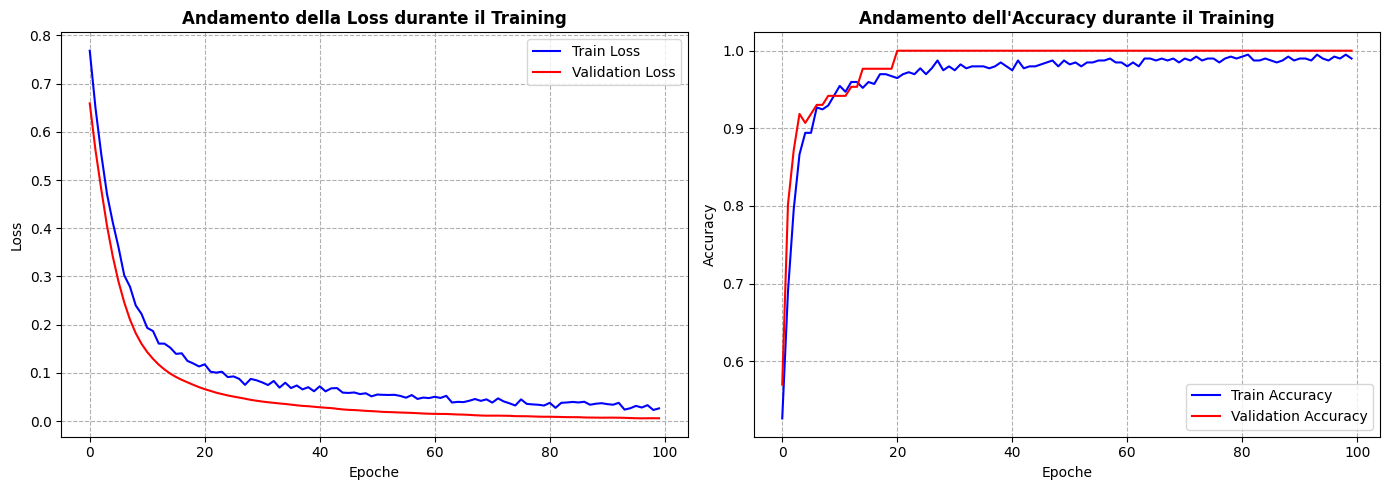

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step

RISULTATI RETE NEURALE SUL TEST SET
Accuracy:  0.9419
Precision: 0.9804
Recall:    0.9259
F1-Score:  0.9524
ROC AUC:   0.9948


In [ ]:
# PARTE 4 (DEEP LEARNING) - PROGETTO APPRENDIMENTO AUTOMATICO E APPRENDIMENTO PROFONDO

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam

# Impostiamo un seed globale per la riproducibilità dei risultati
tf.random.set_seed(42)
np.random.seed(42)

# 1. COSTRUZIONE DELLA RETE NEURALE
model_dl = Sequential([
    # Input + Primo Layer Nascosto
    Dense(16, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    # Dropout per prevenire l'overfitting
    Dropout(0.2),
    # Secondo Layer Nascosto
    Dense(8, activation='relu'),
    # Layer di Output per Classificazione Binaria
    Dense(1, activation='sigmoid')
])

# 2. COMPILAZIONE DEL MODELLO
model_dl.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_dl.summary()

# 3. ADDESTRAMENTO (TRAINING)
# Utilizziamo X_train_scaled e monitoriamo su X_val_scaled (come richiesto)
history = model_dl.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    verbose=1
)

# 4 GRAFICI DELLE CURVE DI APPRENDIMENTO
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Grafico della Loss
ax1.plot(history.history['loss'], label='Train Loss', color='blue')
ax1.plot(history.history['val_loss'], label='Validation Loss', color='red')
ax1.set_title('Andamento della Loss durante il Training', fontsize=12, fontweight='bold')
ax1.set_xlabel('Epoche')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, linestyle='--')

# Grafico dell'Accuracy
ax2.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
ax2.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
ax2.set_title('Andamento dell\'Accuracy durante il Training', fontsize=12, fontweight='bold')
ax2.set_xlabel('Epoche')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, linestyle='--')

plt.tight_layout()
plt.show()

# 5 VALUTAZIONE FINALE SUL TEST SET
# Otteniamo le probabilità predette (valori continui tra 0 e 1)
y_prob_dl = model_dl.predict(X_test_scaled).flatten()
# Convertiamo le probabilità in etichette binarie usando la soglia standard 0.5
y_pred_dl = (y_prob_dl >= 0.5).astype(int)

# Calcolo delle metriche
acc_dl = accuracy_score(y_test, y_pred_dl)
prec_dl = precision_score(y_test, y_pred_dl)
rec_dl = recall_score(y_test, y_pred_dl)
f1_dl = f1_score(y_test, y_pred_dl)
roc_auc_dl = roc_auc_score(y_test, y_prob_dl)

print("\nRISULTATI RETE NEURALE SUL TEST SET")
print(f"Accuracy:  {acc_dl:.4f}")
print(f"Precision: {prec_dl:.4f}")
print(f"Recall:    {rec_dl:.4f}")
print(f"F1-Score:  {f1_dl:.4f}")
print(f"ROC AUC:   {roc_auc_dl:.4f}")